In [1]:
%matplotlib notebook

In [2]:
from Bio.Align import PairwiseAligner, substitution_matrices, Alignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO
import numpy as np
from numpy import random as rd
from matplotlib import pyplot as plt

In [3]:
from src.discrimalign import discrimalign
from src.logit_link import logit_partial_scores
from src.optimization import create_powerstep, create_constant_step

# Data

In [4]:
from miRBench.dataset import list_datasets, get_dataset_df

In [5]:
hejret_train = get_dataset_df(list_datasets()[0], split="train")
hejret_test = get_dataset_df(list_datasets()[0], split="test")

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


In [6]:
mirlist = hejret_train['noncodingRNA']
mirlist = [Seq(seq) for seq in mirlist]
genelist = hejret_train['gene']
genelist = [Seq(seq).reverse_complement() for seq in genelist]

In [7]:
hejret_train

,gene,noncodingRNA,noncodingRNA_name,noncodingRNA_fam,feature,label,chr,start,end,strand,gene_cluster_ID
0,CCCAGGGTGTTTCATGCTGAGGTAGTAGGATGAATAAAGGCAAATA...,CTATACAATCTACTGTCTTTC,hsa-let-7a-3p,let-7,NaN,1,13,103634174,103634223,-,355
1,CAACTCTATACAACACACCTACTATCTCTTGATGCCCTATTGACAG...,TGAGGTAGTAGGTTGTGTGGTT,hsa-let-7a-5p,let-7,exon,1,10,102362496,102362545,+,1611
2,TAGAGGATCCTAGACCAGCATGCCAGTGTGCCAAGGCCACAGGGAA...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,65500706,65500755,+,1457
3,CATCCCCCTGACGGCCGAGAAGCTGTGCATCTACACCGACAACTCC...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,11,69643180,69643229,+,97
4,CAACATGAAACAGTTCATCCGCTACCTCATCTCGTCCAACGTCGGG...,TGAGGTAGTAGGTTGTATAGTT,hsa-let-7a-5p,let-7,exon,1,12,110342392,110342441,+,3303
...,...,...,...,...,...,...,...,...,...,...,...
8188,TGATAGTTCAGCTTGAATGTCTCTTAGAGGGTGGGCTTTTGTTGAT...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,exon,0,11,65502560,65502609,+,2508
8189,GTGGGACTGCTCTGTCCCCTGCCCCTACTGCAGAGATAGCACTGCC...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,three_prime_utr,0,17,49053543,49053592,+,239
8190,CCATTTCTTTGGATTTGCCTCTCCTGGACATTTCATATAGATGAAA...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,intron,0,15,101365823,101365872,-,423
8191,CATCACATGCAGGTGGGCCTGGGCTCCTTGGGAGGAAGTATGGTGG...,CACCCGTAGAACCGACCTTGCG,hsa-miR-99b-5p,mir-10,"intron,exon",0,17,1651376,1651425,-,65


In [8]:
sum(hejret_train['label']==1)

4084

In [9]:
sum(hejret_train['label']==0)

4109

# Optimization

### Simple model on miRNA alignments:

In [11]:
true_match = 1
true_mismatch = -1
true_gapopen = -1.2
true_gapext = -0.1

In [12]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.match = true_match
aligner.mismatch = true_mismatch
# aligner.end_gap_score = 0

In [13]:
mirlist[0]

Seq('CTATACAATCTACTGTCTTTC')

In [14]:
genelist[0]

Seq('TGCATATTTGCCTTTATTCATCCTACTACCTCAGCATGAAACACCCTGGG')

In [15]:
empty_alignment = Alignment(['', ''])

In [16]:
empty_alignment[0]

''

In [17]:
a = next(aligner.align(mirlist[1], genelist[1]), Alignment(['', '']))

In [18]:
next(aligner.align('A', 'T'))

StopIteration: 

In [13]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

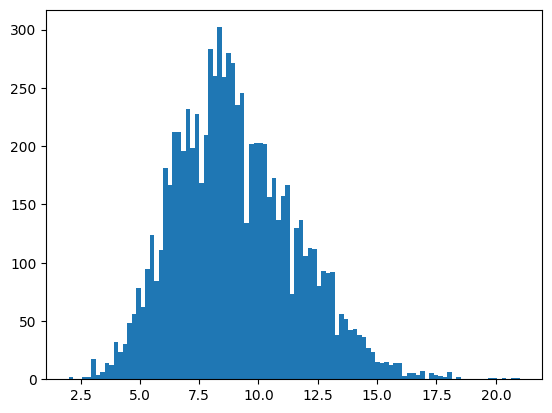

In [14]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [15]:
true_alpha = -9

In [16]:
logit_scores = logit_partial_scores(scores, true_alpha)

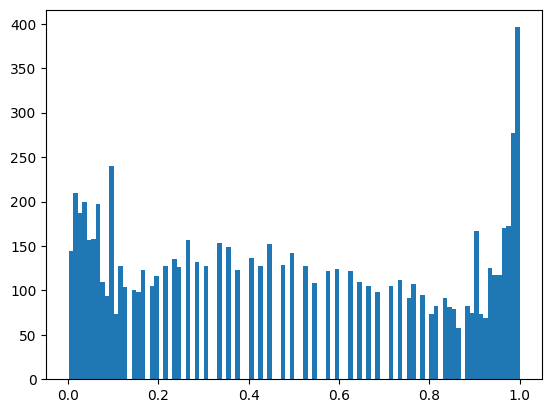

In [17]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [19]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
labels

array([False,  True, False, ..., False, False,  True])

In [20]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -10002.78024009512
True LogL: -3189.780240095122


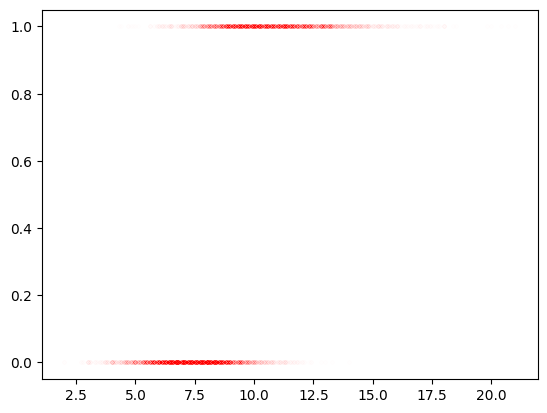

In [21]:
plt.figure()
plt.plot(scores, labels, 'r.', alpha=0.005)

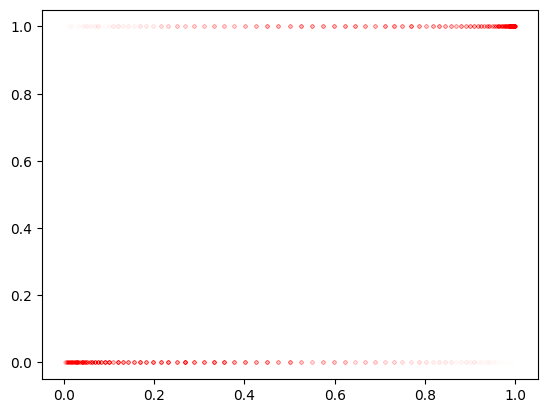

In [22]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.005)

In [36]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [37]:
NITER = 50

In [ ]:
parameters = discrimalign(seqlistA, seqlistB, labels, 
                          aligner_mode='local',
                          substitution_mode='simple',
                          gap_mode = 'affine',
                          max_iter=NITER,
                          stepfunction=const_step,
                          stochastic_factor=0.001,
                          num_threads = 16)

In [43]:
print(params['final_loglik'])

-3191.4601452854713


In [44]:
print(params['final_loglik'])

-3191.4601452854713


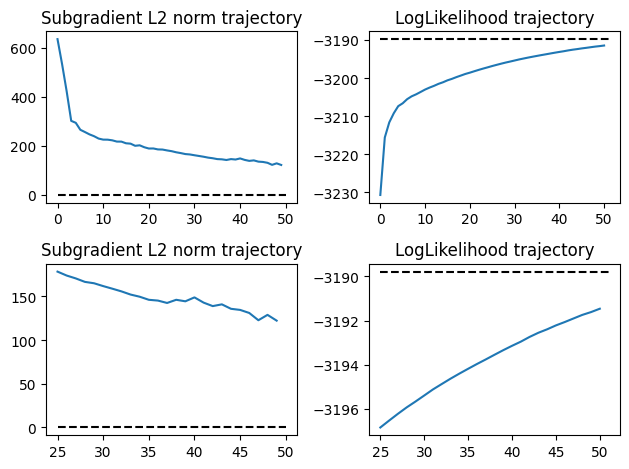

In [45]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

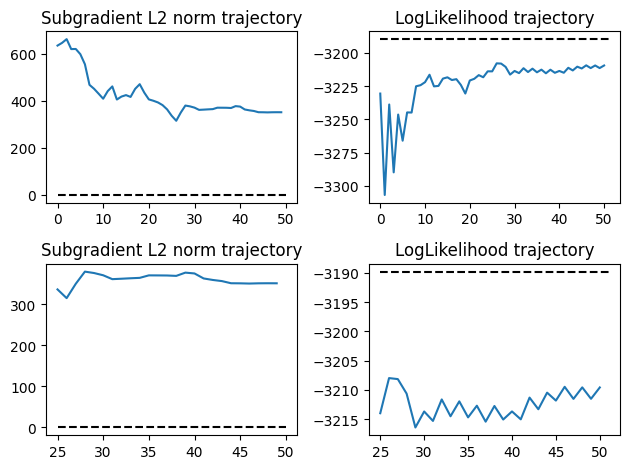

In [29]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [68]:
print(true_match, params['match_score'])
print(true_mismatch, params['mismatch_score'])
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])

1 [0.99043018]
-1 [-0.96008404]
-1.2 [-1.15123837]
-0.1 [-0.10372796]
-9 -9.008323871219716


### Step function parameters experiment

In [71]:
labels = rd.rand(len(mirlist)) <= logit_scores

In [80]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [72]:
steplengts = np.linspace(0.000005, 0.00005, num=10)
steplengts

array([5.0e-06, 1.0e-05, 1.5e-05, 2.0e-05, 2.5e-05, 3.0e-05, 3.5e-05,
       4.0e-05, 4.5e-05, 5.0e-05])

In [83]:
NITER = 10

In [84]:
discrimalign_results = []
for stepl in steplengts:
    const_step = create_constant_step(stepl)
    params = discrimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    discrimalign_results.append(params)


<IPython.core.display.Javascript object>


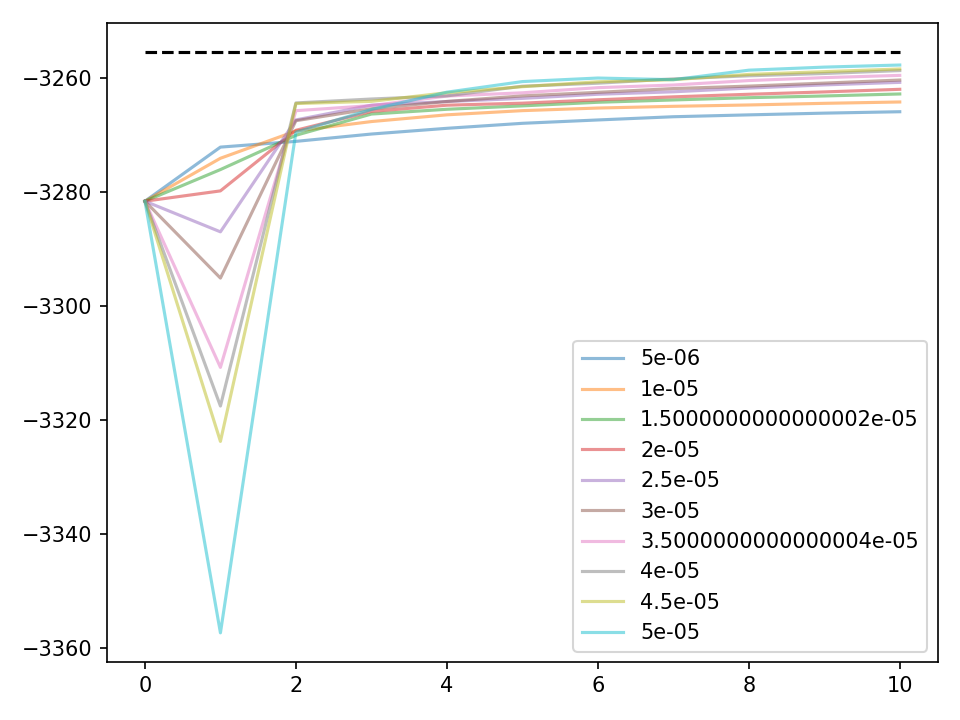

In [91]:
plt.figure()
for params in discrimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend(steplengts)
plt.tight_layout()
# plt.savefig('path', dpi=160)

<IPython.core.display.Javascript object>


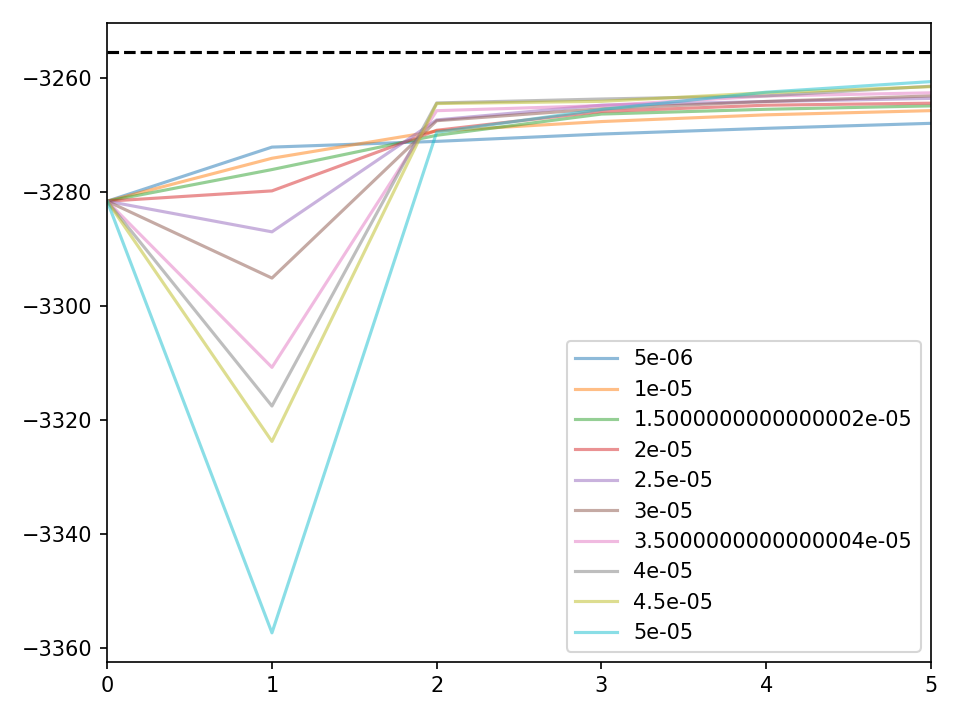

In [90]:
plt.figure()
for params in discrimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.5)
plt.plot([0, NITER], [true_logL, true_logL], 'k--')
plt.legend(steplengts)
plt.xlim(0, 5)
plt.tight_layout()

### Replicates

In [64]:
REPS = 20
NITER = 5

In [65]:
const_step = create_constant_step(0.00001)
# powerstep = create_powerstep(0.00001, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00001, power=-0.5, burnin=0)

In [66]:
discrimalign_results = []
true_logLs = []
for _ in range(REPS):
    labels = rd.rand(len(mirlist)) <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    true_logLs.append(true_logL)
    params = discrimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='simple',
                    gap_mode = 'affine',
                    verbose=False, max_iter=NITER,
                    stochastic_factor=0.001,
                    num_threads = 16)
    discrimalign_results.append(params)


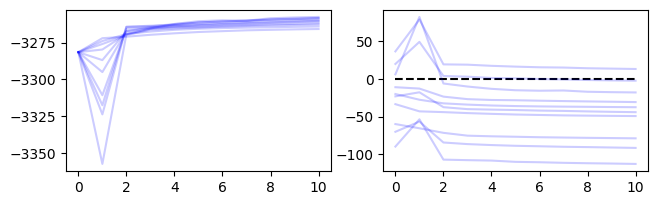

In [85]:
plt.figure(figsize=(7.5, 2.1))
plt.subplot(121)
for params in discrimalign_results:
    plt.plot(np.arange(NITER+1), params['loglik_trajectory'], alpha=0.2, color='b')
plt.subplot(122)
plt.plot([0, NITER], [0, 0], 'k--')
for params, tlL in zip(discrimalign_results, true_logLs):
    plt.plot(np.arange(NITER+1), tlL - params['loglik_trajectory'], alpha=0.2, color='b')

### General matrix, affine gap penalty

In [10]:
true_gapopen = -1.2
true_gapext = -0.1
true_substitution = substitution_matrices.Array(alphabet='ACTG', 
                                          data=np.array([
                                              [1, -0.3, -1, -0.8], 
                                              [-0.6, 1.2, -0.3, -1], 
                                              [-1.2, -0.4, 1, -0.8], 
                                              [-0.4, -1.4, -0.9, 1.3]]))

Symmetric matrix experiment:

In [11]:
true_substitution = (true_substitution + true_substitution.T)/2
true_substitution

Array([[ 1.  , -0.45, -1.1 , -0.6 ],
       [-0.45,  1.2 , -0.35, -1.2 ],
       [-1.1 , -0.35,  1.  , -0.85],
       [-0.6 , -1.2 , -0.85,  1.3 ]],
         alphabet='ACTG')

In [12]:
aligner = PairwiseAligner()
aligner.mode = 'local'
aligner.open_gap_score = true_gapopen
aligner.extend_gap_score = true_gapext
aligner.substitution_matrix = true_substitution

In [13]:
scores = np.array([aligner.score(a, b) for a, b in zip(mirlist, genelist)])

<IPython.core.display.Javascript object>


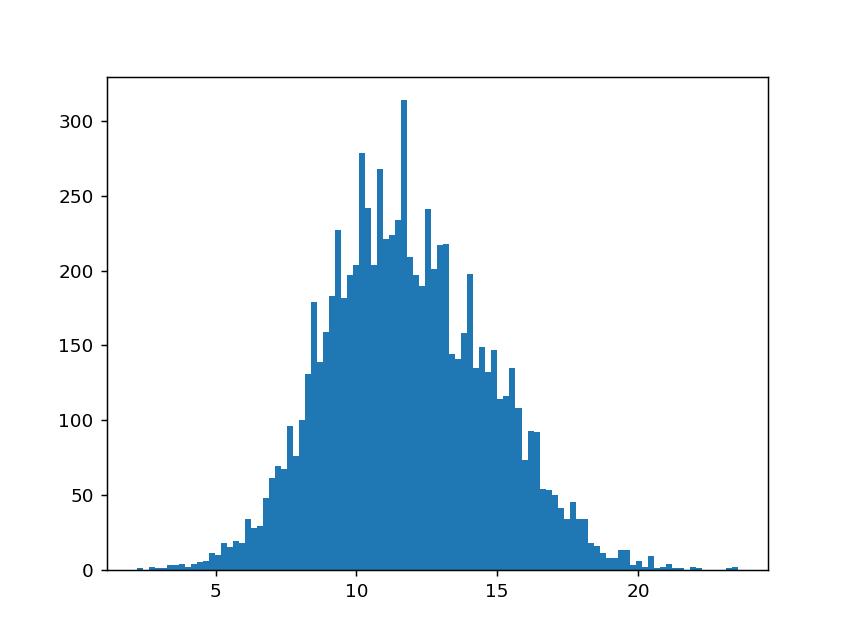

In [14]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [15]:
true_alpha = -12
logit_scores = logit_partial_scores(scores, true_alpha)

<IPython.core.display.Javascript object>


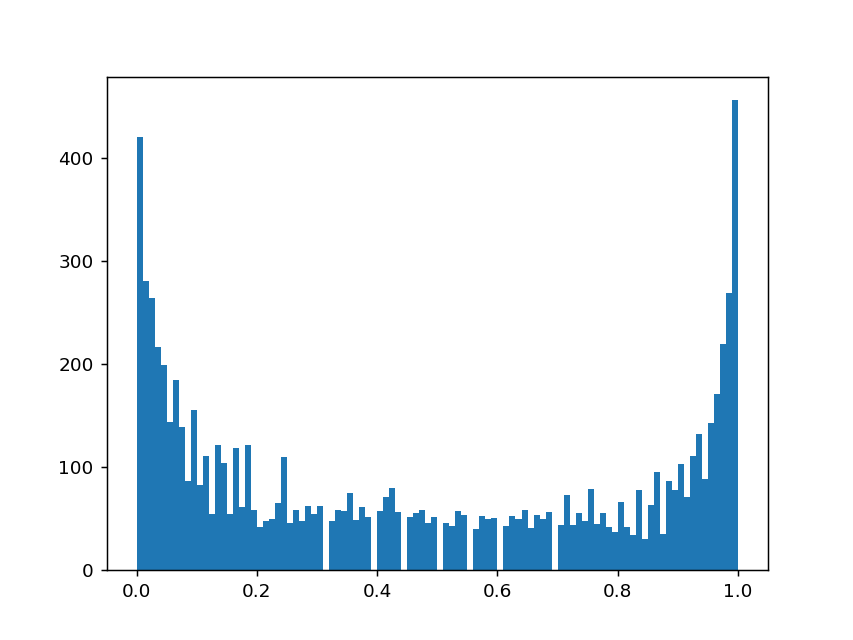

In [16]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

In [17]:
labels = rd.rand(len(mirlist))
labels = labels <= logit_scores
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -11842.534178606267
True LogL: -2836.684178606274


In [18]:
const_step = create_constant_step(4e-05)
# powerstep = create_powerstep(0.00005, power=0.5, burnin=0)
# powerstep = create_powerstep(0.00002, power=-0.1, burnin=0)

In [19]:
NITER = 200

In [23]:
params = discrimalign(mirlist, genelist, labels, 
                    stepfunction=const_step,
                    aligner_mode='local',
                    substitution_mode='symmetric',
                    gap_mode='affine', 
                    stochastic_factor=0.001,
                    verbose=True, max_iter=NITER,
                    num_threads = 24, 
                     alphabet='ACTG')

Alphabet:
ACTG
Initial parameters:
{'alpha': -9.863021533617339, 'substitution_matrix': Array([[ 0.8715944 , -0.56556373, -0.81242831, -0.63435836],
       [-0.56556373,  1.09227914, -0.46240318, -0.92870697],
       [-0.81242831, -0.46240318,  0.85959108, -0.71463421],
       [-0.63435836, -0.92870697, -0.71463421,  1.19335374]],
         alphabet='ACTG'), 'open_gap_score': -1.20479959957369, 'extend_gap_score': -0.0915590051538091}
Start of iteration 0
Current alpha: -9.863021533617339
Current logL: -2930.5476471978336
Updated alpha: -10.164130082046368
Updated logL: -2885.1249663879016
New subgradient:
{'Substitutions': Array([[ 99.93353882,   5.33535398,  -6.22167768,   9.96260062],
       [ 29.97150215, 115.05161314,  12.18012277, -19.32565356],
       [-11.24260023,  53.68334903, 146.99886719, -40.5661019 ],
       [ 30.54542531, -29.21165964,  -1.18417975, 129.3556512 ]],
         alphabet='ACTG'), 'Gap opens': 197.93375409704396, 'Gap extends': 286.2376891831341}
Stepsize: 4e-0

Current alpha: -10.958152073661056
Current logL: -2864.462226171198
Updated alpha: -11.04513569693121
Updated logL: -2860.767390610978
New subgradient:
{'Substitutions': Array([[ 56.82573091,  -1.16844602, -10.42179103,  11.07948475],
       [ 26.24747442,  58.39606311,  11.36483188, -16.06481308],
       [-14.11258009,  52.84044548,  51.98976109, -38.42962262],
       [ 30.45362511, -30.05747724,  -4.53659214,  67.64276915]],
         alphabet='ACTG'), 'Gap opens': 64.45520165940519, 'Gap extends': -33.60411244449089}
Stepsize: 4e-05
Gap open step: 0.0025782080663762077
Gap extend step: -0.0013441644977796356
New parameters:
{'alpha': -11.04513569693121, 'substitution_matrix': Array([[ 0.91942849, -0.55683656, -0.81853981, -0.62017266],
       [-0.55683656,  1.14555099, -0.44151867, -0.94301393],
       [-0.81853981, -0.44151867,  0.9135626 , -0.72845348],
       [-0.62017266, -0.94301393, -0.72845348,  1.24872653]],
         alphabet='ACTG'), 'open_gap_score': -1.1704565383454664, 'e

Current alpha: -11.474490669389988
Current logL: -2852.7516437588915
Updated alpha: -11.526366867442176
Updated logL: -2851.4583208492263
New subgradient:
{'Substitutions': Array([[ 33.70023274,  -0.53632044, -12.12632362,   9.87662342],
       [ 20.48617341,  33.9474828 ,  11.07622129, -15.86495546],
       [ -9.84778188,  46.19221436,  30.82763504, -39.55107916],
       [ 36.06299756, -31.10276431,  -6.89248816,  43.14082378]],
         alphabet='ACTG'), 'Gap opens': 18.370124605361188, 'Gap extends': -16.539905272565754}
Stepsize: 4e-05
Gap open step: 0.0007348049842144476
Gap extend step: -0.0006615962109026302
New parameters:
{'alpha': -11.526366867442176, 'substitution_matrix': Array([[ 0.94546524, -0.55014876, -0.82604089, -0.6062919 ],
       [-0.55014876,  1.17355292, -0.4215158 , -0.95767015],
       [-0.82604089, -0.4215158 ,  0.93781951, -0.7434888 ],
       [-0.6062919 , -0.95767015, -0.7434888 ,  1.27946151]],
         alphabet='ACTG'), 'open_gap_score': -1.16127328849225

Current alpha: -11.798449285794705
Current logL: -2846.5451573204596
Updated alpha: -11.827210999404869
Updated logL: -2846.151726717168
New subgradient:
{'Substitutions': Array([[ 23.5742095 ,  -2.48173806, -14.64609868,   5.36434826],
       [ 24.38695435,  21.71749745,   9.01590175, -12.70516558],
       [ -9.34763086,  36.51325901,  24.21627758, -38.17073826],
       [ 33.44925466, -28.84119323,  -5.46154043,  28.36417206]],
         alphabet='ACTG'), 'Gap opens': 0.06750030475518853, 'Gap extends': 6.208946932227691}
Stepsize: 4e-05
Gap open step: 2.7000121902075417e-06
Gap extend step: 0.00024835787728910767
New parameters:
{'alpha': -11.827210999404869, 'substitution_matrix': Array([[ 0.96474586, -0.54355419, -0.8333726 , -0.59279823],
       [-0.54355419,  1.19186685, -0.40562924, -0.97116616],
       [-0.8333726 , -0.40562924,  0.95444565, -0.75752857],
       [-0.59279823, -0.97116616, -0.75752857,  1.29903539]],
         alphabet='ACTG'), 'open_gap_score': -1.159639781081143

Current alpha: -12.002420073998563
Current logL: -2842.865433285197
Updated alpha: -12.014366967031448
Updated logL: -2842.798020787874
New subgradient:
{'Substitutions': Array([[ 17.72158546,  -3.20465824, -14.08908008,   4.10425847],
       [ 21.82742633,  16.55703497,   9.51603347, -12.82521315],
       [-10.31929031,  28.90056417,  15.61618255, -38.37993119],
       [ 33.21549706, -28.999268  ,  -3.19464751,  18.6774767 ]],
         alphabet='ACTG'), 'Gap opens': -8.85458275941998, 'Gap extends': 11.590637928116033}
Stepsize: 4e-05
Gap open step: -0.00035418331037679923
Gap extend step: 0.00046362551712464135
New parameters:
{'alpha': -12.014366967031448, 'substitution_matrix': Array([[ 0.9771868 , -0.53744154, -0.84067786, -0.58118947],
       [-0.53744154,  1.20331838, -0.39300682, -0.98393196],
       [-0.84067786, -0.39300682,  0.9653601 , -0.77109937],
       [-0.58118947, -0.98393196, -0.77109937,  1.31239732]],
         alphabet='ACTG'), 'open_gap_score': -1.1625861675121805

...

Current alpha: -12.586356678502531
Current logL: -2828.0660609518895
Updated alpha: -12.579182870526735
Updated logL: -2828.0425497916262
New subgradient:
{'Substitutions': Array([[  2.63857949, -10.92849826, -10.73197668, -11.16111144],
       [ 11.19689486,   1.75950058,  -5.4209101 ,  -2.07250266],
       [  0.08964151,   3.64755084,   4.68310413, -21.33629596],
       [ 12.37982613, -17.12557747,  10.83002405,   6.05465689]],
         alphabet='ACTG'), 'Gap opens': -2.5917755392032262, 'Gap extends': 32.28520229439933}
Stepsize: 4e-05
Gap open step: -0.00010367102156812905
Gap extend step: 0.0012914080917759735
New parameters:
{'alpha': -12.579182870526735, 'substitution_matrix': Array([[ 1.02100446, -0.48499289, -0.93708695, -0.52225209],
       [-0.48499289,  1.25296499, -0.35454271, -1.14148028],
       [-0.93708695, -0.35454271,  1.01411312, -0.89688255],
       [-0.52225209, -1.14148028, -0.89688255,  1.36981537]],
         alphabet='ACTG'), 'open_gap_score': -1.22314327553180

Current alpha: -12.59653343460068
Current logL: -2827.8363836438225
Updated alpha: -12.60257464884166
Updated logL: -2827.8197179280633
New subgradient:
{'Substitutions': Array([[  3.14726368, -10.60675689, -11.29782683, -11.4801127 ],
       [ 10.67158368,   1.80955863,  -6.25316829,  -1.93427764],
       [  0.25298577,   3.8990125 ,   0.18081132, -21.03146126],
       [ 11.47647543, -16.84802773,  11.00907222,   0.76096039]],
         alphabet='ACTG'), 'Gap opens': -5.902419475101489, 'Gap extends': -12.84143702931761}
Stepsize: 4e-05
Gap open step: -0.00023609677900405957
Gap extend step: -0.0005136574811727045
New parameters:
{'alpha': -12.60257464884166, 'substitution_matrix': Array([[ 1.02234921, -0.48488424, -0.94067541, -0.52206197],
       [-0.48488424,  1.25446941, -0.35547585, -1.14771926],
       [-0.94067541, -0.35547585,  1.01534437, -0.90011845],
       [-0.52206197, -1.14771926, -0.90011845,  1.37107791]],
         alphabet='ACTG'), 'open_gap_score': -1.2245336675905105

Current alpha: -12.60708156992575
Current logL: -2827.603329817855
Updated alpha: -12.607901910637818
Updated logL: -2827.6030227667948
New subgradient:
{'Substitutions': Array([[  1.82113336, -10.2694879 , -12.30677367, -10.7257624 ],
       [ 10.38328458,   1.40763121,  -6.34310756,  -1.40296346],
       [ -1.49172618,   3.90106095,   2.51918512, -20.08790984],
       [ 10.36109281, -16.57770257,  11.26663074,   1.78696069]],
         alphabet='ACTG'), 'Gap opens': -3.2515402984697013, 'Gap extends': 0.29297002604048317}
Stepsize: 4e-05
Gap open step: -0.00013006161193878805
Gap extend step: 1.1718801041619328e-05
New parameters:
{'alpha': -12.607901910637818, 'substitution_matrix': Array([[ 1.0241097 , -0.48487258, -0.94507949, -0.52195186],
       [-0.48487258,  1.25539399, -0.35645571, -1.15364079],
       [-0.94507949, -0.35645571,  1.01723212, -0.90306243],
       [-0.52195186, -1.15364079, -0.90306243,  1.37158027]],
         alphabet='ACTG'), 'open_gap_score': -1.2255162947933

Current alpha: -12.618528644335987
Current logL: -2827.404989065416
Updated alpha: -12.618069960458756
Updated logL: -2827.4048931478237
New subgradient:
{'Substitutions': Array([[  1.5750307 , -10.19896272, -11.9012017 , -11.15621825],
       [ 10.10468451,   0.94792314,  -7.05468891,  -2.24171249],
       [ -1.36617713,   3.92457425,   3.2464296 , -21.20246227],
       [ 10.73793867, -16.50256684,  11.47907406,   1.9542068 ]],
         alphabet='ACTG'), 'Gap opens': -0.7833711335699823, 'Gap extends': 7.610203848339339}
Stepsize: 4e-05
Gap open step: -3.1334845342799296e-05
Gap extend step: 0.00030440815393357356
New parameters:
{'alpha': -12.618069960458756, 'substitution_matrix': Array([[ 1.02543616, -0.48488795, -0.94932297, -0.52211754],
       [-0.48488795,  1.25646635, -0.35728046, -1.15944177],
       [-0.94932297, -0.35728046,  1.01838075, -0.9058357 ],
       [-0.52211754, -1.15944177, -0.9058357 ,  1.37271317]],
         alphabet='ACTG'), 'open_gap_score': -1.22638920157245

Current alpha: -12.629156563882468
Current logL: -2827.2058716180104
Updated alpha: -12.629928586563471
Updated logL: -2827.2056000448692
New subgradient:
{'Substitutions': Array([[  2.06039167, -10.05609096, -11.69474821, -10.80649725],
       [  9.96746495,   1.59587358,  -6.86848126,  -1.98210309],
       [ -0.76488846,   4.70382093,   0.57133785, -21.02278653],
       [ 11.18606178, -16.23623818,  12.24353647,   1.49966513]],
         alphabet='ACTG'), 'Gap opens': -2.888924400824659, 'Gap extends': -0.32236675100468837}
Stepsize: 4e-05
Gap open step: -0.00011555697603298637
Gap extend step: -1.2894670040187536e-05
New parameters:
{'alpha': -12.629928586563471, 'substitution_matrix': Array([[ 1.02674874, -0.48492337, -0.95339986, -0.52204057],
       [-0.48492337,  1.25744383, -0.35811926, -1.16531621],
       [-0.95339986, -0.35811926,  1.0192355 , -0.90876696],
       [-0.52204057, -1.16531621, -0.90876696,  1.37363878]],
         alphabet='ACTG'), 'open_gap_score': -1.2270434176

In [24]:
print(params['final_loglik'])

-2827.182472907623


<IPython.core.display.Javascript object>


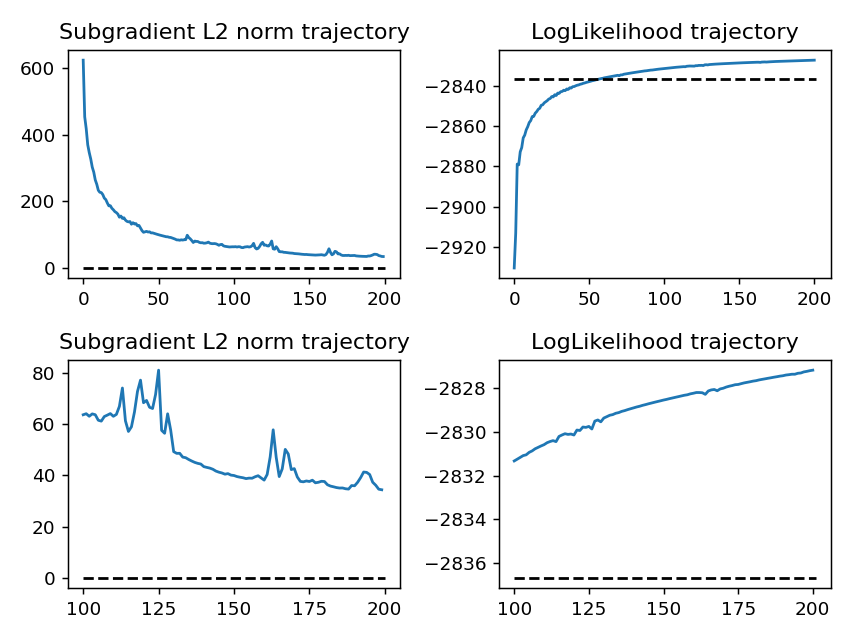

In [25]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')


plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [26]:
print(true_substitution)
print(params['substitution_matrix'])

     A    C    T    G
A  1.0 -0.4 -1.1 -0.6
C -0.4  1.2 -0.3 -1.2
T -1.1 -0.3  1.0 -0.9
G -0.6 -1.2 -0.9  1.3

     A    C    T    G
A  1.0 -0.5 -1.0 -0.5
C -0.5  1.3 -0.4 -1.2
T -1.0 -0.4  1.0 -0.9
G -0.5 -1.2 -0.9  1.4



In [27]:
print(true_gapopen, params['open_gap_score'])
print(true_gapext, params['extend_gap_score'])
print(true_alpha, params['alpha'])
true_subs_vector = []
param_subs_vector = []
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        true_v = true_substitution[char1, char2]
        true_subs_vector.append(true_v)
        estim_v = params['substitution_matrix'][char1, char2]
        param_subs_vector.append(estim_v)
        print(char1, char2, true_v, estim_v)
        
print(np.corrcoef(true_subs_vector, param_subs_vector))
print(np.mean(np.abs(np.array(true_subs_vector)- np.array(param_subs_vector))))

-1.2 -1.2270434176211626
-0.1 -0.10834394069233623
-12 -12.629928586563471
A A 1.0 1.0267487377405369
A C -0.44999999999999996 -0.4849233680222277
A T -1.1 -0.9533998623370106
A G -0.6000000000000001 -0.5220405715276891
C A -0.44999999999999996 -0.4849233680222277
C C 1.2 1.2574438259884624
C T -0.35 -0.35811925602648437
C G -1.2 -1.1653162052565809
T A -1.1 -0.9533998623370106
T C -0.35 -0.35811925602648437
T T 1.0 1.0192354987503742
T G -0.8500000000000001 -0.9087669639542324
G A -0.6000000000000001 -0.5220405715276891
G C -1.2 -1.1653162052565809
G T -0.8500000000000001 -0.9087669639542324
G G 1.3 1.373638776587913
[[1.         0.99741818]
 [0.99741818 1.        ]]
0.05619829605191341


<IPython.core.display.Javascript object>


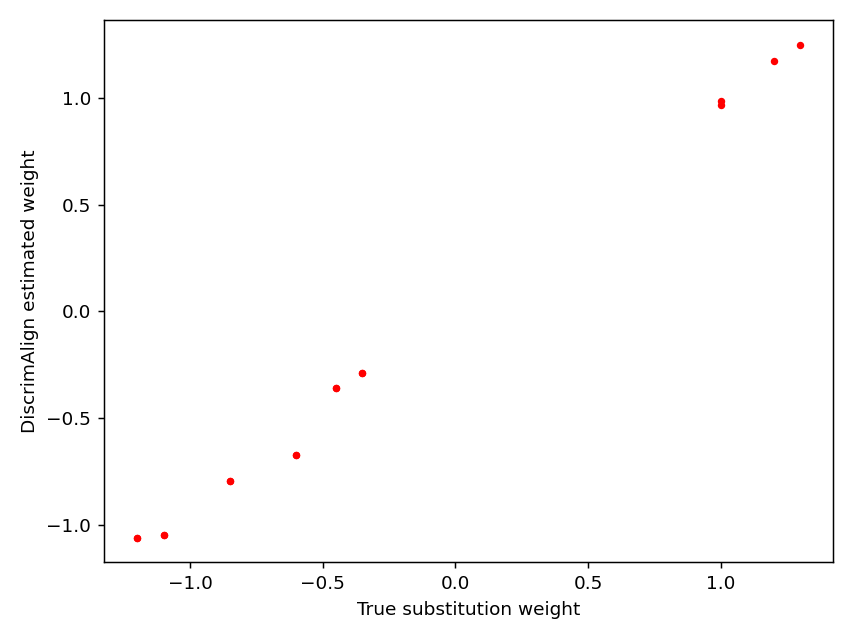

In [50]:
plt.figure()
plt.plot(true_subs_vector, param_subs_vector, 'r.')
plt.xlabel('True substitution weight')
plt.ylabel('DiscrimAlign estimated weight')
plt.tight_layout()
plt.savefig('Figs/DNA_hejret_simulation.png', dpi=160)

In [28]:
from src.optimization import get_initial_estimate

In [29]:
get_initial_estimate(params['alignments'], labels, substitution_mode='general', gap_mode='affine',
                     alphabet=true_substitution.alphabet)

{'alpha': -12.510359651242187,
 'substitution_matrix': Array([[ 1.035747  , -0.28576212, -1.00725787, -0.76980938],
        [-0.62016007,  1.24445203, -0.27855495, -0.92460282],
        [-1.23395366, -0.41371352,  1.02576908, -0.76105004],
        [-0.40423938, -1.36785736, -0.93451928,  1.34210605]],
          alphabet='ACTG'),
 'open_gap_score': -1.2412442385557685,
 'extend_gap_score': -0.0943680233961867}

In [30]:
true_substitution

Array([[ 1. , -0.3, -1. , -0.8],
       [-0.6,  1.2, -0.3, -1. ],
       [-1.2, -0.4,  1. , -0.8],
       [-0.4, -1.4, -0.9,  1.3]],
         alphabet='ACTG')

In [34]:
estim_substitution = true_substitution.copy()
for char1 in true_substitution.alphabet:
    for char2 in true_substitution.alphabet:
        estim_substitution[char1, char2] = params['substitution_matrix'][char1, char2]

In [35]:
estim_substitution

Array([[ 1.00594523, -0.28336624, -0.89812056, -0.70795647],
       [-0.60064739,  1.21399157, -0.27566044, -0.82455326],
       [-1.08766538, -0.40324117,  0.99435569, -0.7373319 ],
       [-0.38899072, -1.03386793, -0.84718049,  1.3087618 ]],
         alphabet='ACTG')

# Proteins

### Simulated alignments

In [339]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [351]:
coupling = 2**blosum62/(len(blosum62.alphabet)**2)
coupling /= np.sum(coupling)

In [355]:
aa_pairs = [(char1, char2) for char1 in blosum62.alphabet for char2 in blosum62.alphabet]
prob_vect = [coupling[aapair] for aapair in aa_pairs]

In [363]:
for aa, prob in zip(aa_pairs, prob_vect):
    print(aa, prob)

('A', 'A') 0.003933257536182897
('A', 'R') 0.00012291429800571552
('A', 'N') 6.145714900285776e-05
('A', 'D') 6.145714900285776e-05
('A', 'C') 0.00024582859601143104
('A', 'Q') 0.00012291429800571552
('A', 'E') 0.00012291429800571552
('A', 'G') 0.00024582859601143104
('A', 'H') 6.145714900285776e-05
('A', 'I') 0.00012291429800571552
('A', 'L') 0.00012291429800571552
('A', 'K') 0.00012291429800571552
('A', 'M') 0.00012291429800571552
('A', 'F') 6.145714900285776e-05
('A', 'P') 0.00012291429800571552
('A', 'S') 0.0004916571920228621
('A', 'T') 0.00024582859601143104
('A', 'W') 3.072857450142888e-05
('A', 'Y') 6.145714900285776e-05
('A', 'V') 0.00024582859601143104
('A', 'B') 6.145714900285776e-05
('A', 'Z') 0.00012291429800571552
('A', 'X') 0.00024582859601143104
('A', '*') 1.536428725071444e-05
('R', 'A') 0.00012291429800571552
('R', 'R') 0.007866515072365793
('R', 'N') 0.00024582859601143104
('R', 'D') 6.145714900285776e-05
('R', 'C') 3.072857450142888e-05
('R', 'Q') 0.0004916571920228

In [353]:
SETSIZE = 5000

In [359]:
Alist = []
Blist = []
for _ in range(SETSIZE):
    pairs = rd.choice(len(aa_pairs), p=prob_vect, replace=True, size=250)
    pairs = [aa_pairs[i] for i in pairs]
    aseq = ''.join(x[0] for x in pairs)
    bseq = ''.join(x[1] for x in pairs)
    Alist.append(aseq)
    Blist.append(bseq)

In [361]:
Blist

['CLWHWMHDWWHWWWWCHCWCCHYWCKFWHWWWYNHCWWWIWWWWCWWWWWCYDCCWWWWHCSTGWCWQYRYWWWWEHFWCWWPWBHCCILNWMPWCWYWEIHHWNQCWCPYWWWGWCWWNWWWWYWWCWWPCWNQXIZNFCPWCWWWWCWRCFYWCWWGWWCCWWQWNWWCCWQBEYWEWWMWWWCWEWWWYWWWWDVWYCVZZCWPCWWCWWEPWWWGWZMDWHFWWQWPCWCHWWWCWWWCWWWCQWW',
 'WWWDWCZYWWRBHWHHCWKWWWHWWWWWCYWTWHEWWNWVWGWCWHWWYFWWLWWGWHCQBCNFWYWWHTWWPDWWDWHCWCWWSWWWHSBWWWPWWNBZWYHWWWWQHYWTZWWWCRFWWWPWWWCWWHWWWWYHWMGCCCCQHPWWWYLYWWWWWWPWWZWCQWCWGQWHWHYWKWEWPWWPWCCCCWWWWWWYRWCWEWCHYWWWZWWCWWPCWWWWWCWCCWYGWWWWWWCWWWWIWWHWCWFZPH',
 'NWHWWCWNWWWWLWWWWHWWWHWWWWCWWWWCQTWWNCWWVWWDYWFCWCDWCCGHCRWWWCWWQHWCDDWYWDWRAWDWWWWWCCGPLPLWWWWNWZKWWTTWWGWCCYWCWCEWWNKWBCHWYYWWWBWWZWWWWWWWWWWWWAPWCCNYWHLHWNWCWWEYNWYCWCWWWHHWWWKWWWDWDTWWWWFCWHAWWWPCWHWBHWEVWHVLCCHCWWWWWPCYKEHWWGWWDMWWDWWCWWYWHWWMPF',
 'WWWMWWHCWCWHFWCFHWCPWYCWWHWKWWWWWWWYCAWWRWHHWWBWHWWFFWHWWWPWWWWWPWVDWWQWNHWNQFNWQWWBHWCWPWXWWHWCCCHWEYDHCWYCWCWNWHWFWCWZWWWSPWWWDWWGWWYWWWWHHGHWWWWWWHWPCWCHCAWWWWTWCWWHWWAKWPWWHNPBVWCWHWWHWWAKNWWWWHWWCWPZWKBPPTWWWWWFDHWWIMCSWPZWHWWWE

### Symmetric matrix on protein alignments:

In [112]:
positive_id_tuples = []
close_negative_id_tuples = []
with open('./Proteomes/human_to_chicken_upto1000aa.blast') as h:
    for l in h:
        l = l.split('\t')
        evalue = float(l[-2])
        if evalue == 0:
            positive_id_tuples.append([l[0], l[1]])
        elif evalue > 0.0001:
            close_negative_id_tuples.append([l[0], l[1]])

In [113]:
human_proteome = list(SeqIO.parse('Proteomes/GCF_000001405.40/up_to_1000.faa', 'fasta'))
chick_proteome = list(SeqIO.parse('Proteomes/GCF_016699485.2/up_to_1000.faa', 'fasta'))

In [121]:
alphabet = 'ACDEFGHIKLMNPQRSTVWY'

In [122]:
human_proteome = [seq for seq in human_proteome if set(str(seq.seq)).issubset(set(alphabet))]
chick_proteome = [seq for seq in chick_proteome if set(str(seq.seq)).issubset(set(alphabet))]

In [124]:
human_prot_ids = [seq.id for seq in human_proteome]
chick_prot_ids = [seq.id for seq in chick_proteome]

In [130]:
human_prot_ids_set = set(human_prot_ids)
chick_prot_ids_set = set(chick_prot_ids)

In [131]:
positive_id_tuples = [t for t in positive_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]
# close_negative_id_tuples = [t for t in close_negative_id_tuples if t[0] in human_prot_ids_set and t[1] in chick_prot_ids_set]

In [286]:
SETSIZE = 5000

In [287]:
# pos_set = rd.choice(len(positive_id_tuples), SETSIZE//2, replace=False)
# neg_set = rd.choice(len(close_negative_id_tuples), SETSIZE//2, replace=False)
# prot_dset = [positive_id_tuples[i] for i in pos_set] + [close_negative_id_tuples[i] for i in neg_set]
pos_set = rd.choice(len(positive_id_tuples), SETSIZE, replace=False)
prot_dset = [positive_id_tuples[i] for i in pos_set]

In [288]:
human_list = [human_proteome[human_prot_ids.index(hpid)] for hpid, cpid in prot_dset]
chick_list = [chick_proteome[chick_prot_ids.index(cpid)] for hpid, cpid in prot_dset]

In [289]:
blosum62 = substitution_matrices.load('BLOSUM62')

In [290]:
blosum62 /= np.sqrt(np.sum(blosum62**2))

In [293]:
aligner = PairwiseAligner()
aligner.mode = 'global'
aligner.substitution_matrix=blosum62
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.1

Example scores of alignments to visualize gap open and extend penalties for global alignment:

In [294]:
test_aln = aligner.align('ATA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1, test_aln.score)
test_aln = aligner.align('ATTA', 'AA')
print(next(test_aln))
print(2*blosum62['A', 'A'] - 1 - 0.1, test_aln.score)

target            0 ATA 3
                  0 |-| 3
query             0 A-A 2

-0.866998755185649 -0.8669987551856488
target            0 ATTA 4
                  0 |--| 4
query             0 A--A 2

-0.9669987551856489 -0.9669987551856489


In [295]:
scores = np.array([aligner.score(a, b) for a, b in zip(human_list, chick_list)])

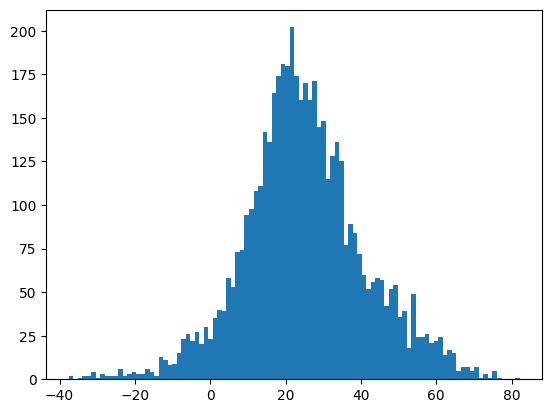

In [296]:
plt.figure()
plt.hist(scores, bins=100)
plt.show()

In [297]:
print(next(aligner.align(human_list[0], chick_list[0])))

XP_047305         0 MWRECDWGLGAVKSDLACVPSAKRLLCRMSNKDRHIDSSCSSFIKTEPSSPASLTDSVNH
                  0 ----------------------------||.|||||||||||.||||||||||||||.||
NP_001383         0 ----------------------------MSSKDRHIDSSCSSYIKTEPSSPASLTDSINH

XP_047305        60 HSPGGSSDASGSYSSTMNGHQNGLDSPPLYPSAPILGGSGPVRKLYDDCSSTIVEDPQTK
                 60 |||||||||||||||||||||||||||||||||..|||.|||||.||||||||.||.|||
NP_001383        32 HSPGGSSDASGSYSSTMNGHQNGLDSPPLYPSATGLGGNGPVRKRYDDCSSTIAEDSQTK

XP_047305       120 CEYMLNSMPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPATNECEITKR
                120 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
NP_001383        92 CEYMLNSMPKRLCLVCGDIASGYHYGVASCEACKAFFKRTIQGNIEYSCPATNECEITKR

XP_047305       180 RRKSCQACRFMKCLKVGMLKEGVRLDRVRGGRQKYKRRIDAENSPYLNPQLVQPAKKPLL
                180 ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||.-
NP_001383       152 RRKSCQACRFMKCLKVGMLKEGVRLDRVRGGRQKYKRRIDAENSPYLNPQLVQPAKKPY-

XP_047305       240 WSDP

In [299]:
logit_scores = logit_partial_scores(scores, -20)

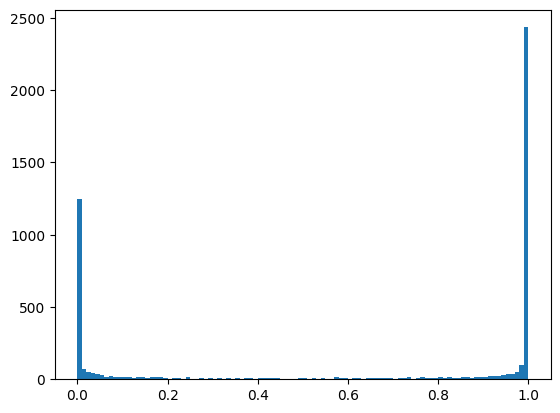

In [300]:
plt.figure()
plt.hist(logit_scores, bins=100)
plt.show()

Expectation check:

In [301]:
logL_distribution = []
for _ in range(5000):
    labels = rd.rand(len(human_list))
    labels = labels <= logit_scores
    true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))
    logL_distribution.append(true_logL)

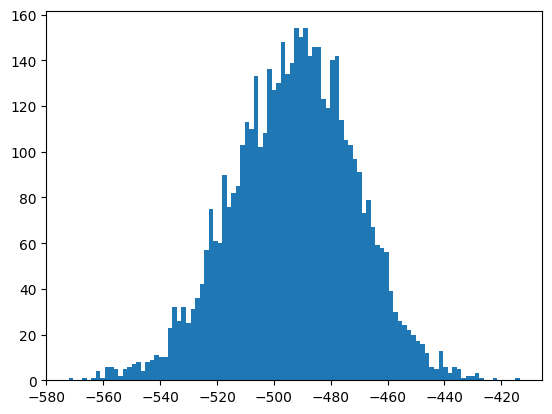

In [302]:
plt.figure()
plt.hist(logL_distribution, bins=100)
plt.show()

In [303]:
EL = 0 
VL = 0
for ls in logit_scores:
    if 1e-24 < ls < 1-1e-24:
        EL += ls*np.log(ls) + (1-ls)*np.log(1-ls)
        VL += ls*(1-ls)*(np.log(ls)**2 + np.log(1-ls)**2) # Incorrect
SDL = np.sqrt(VL)

In [304]:
print('Expected LogL:', EL)
print('Average LogL:', np.mean(logL_distribution))
print('STD LogL:', SDL)
print('Sample STD:', np.std(logL_distribution))

Expected LogL: -492.961331556755
Average LogL: -492.83136372138114
STD LogL: 23.83982117588265
Sample STD: 21.590079372381034


Fitting:

In [321]:
labels = rd.rand(len(human_list))
labels = labels <= logit_scores

In [322]:
true_logL = np.sum(np.log(logit_scores[labels]))+np.sum(np.log(1-logit_scores[~labels]))

In [323]:
print('Sum of log-logit scores:', np.sum(np.log(logit_scores)))
print('True LogL:', true_logL)

Sum of log-logit scores: -19494.686981856918
True LogL: -473.3818560942222


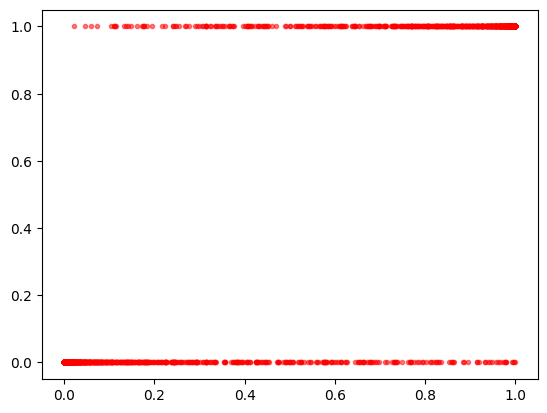

In [324]:
plt.figure()
plt.plot(logit_scores, labels, 'r.', alpha=0.5)

In [325]:
const_step = create_constant_step(0.00005)
powerstep = create_powerstep(0.000005, power=0.5, burnin=0) # step 0.00005 good for SETSIZE==1000
# powerstep = create_powerstep(0.0000001, power=-0.5, burnin=0)

In [326]:
NITER = 50

In [327]:
set('WEIMFASVCGKLTHDPRNQY') == set(alphabet) 

True

In [328]:
params = discrimalign(human_list, chick_list, labels, 
                    stepfunction=powerstep,
                    aligner_mode='global',
                    substitution_mode='general',
                    gap_mode='affine',
                    baseline_aligner=aligner,
                    stochastic_factor=0.0001,
                    verbose=True, max_iter=NITER,
                    num_threads = 16)

Alphabet:
WEIMFASVCGKLTHDPRNQY
Initial parameters:
{'alpha': -35.101053302810854, 'substitution_matrix': Array([[ 3.48825056e-01,  5.99924929e-01,  4.17629018e-01,
        -3.73187553e-01,  2.80712973e-01, -1.92579665e-01,
         3.63649868e-01,  9.24646410e-02, -1.82697874e-01,
        -6.20571638e-01, -1.54715365e-02,  6.81000778e-01,
         1.58561460e-01, -4.91615555e-01,  1.05286898e-03,
        -2.14071773e-01, -1.38160217e-01, -1.69362192e-01,
         6.91424458e-01, -3.87961231e-01],
       [-4.95390953e-01,  1.48953091e-01, -6.88399086e-02,
         6.09065215e-01, -1.43467004e+00,  9.93699223e-02,
        -4.62401007e-02,  1.67419103e-01,  3.88079948e-01,
        -3.55739288e-01,  8.98176490e-02, -1.61843964e-01,
         5.73399833e-01, -2.31427963e-01,  2.02452881e-01,
        -4.76874094e-01,  1.77812210e-01, -3.45593184e-01,
         1.37161711e-01, -8.47186878e-01],
       [-6.42274608e-01, -3.10288428e-01,  8.40838074e-02,
        -1.61377649e-01, -5.64385627e-02, 

New subgradient:
{'Substitutions': Array([[  -47.7684489 ,  -220.26929544,  -105.50773594,    -7.01214256,
          -76.02983061,   -48.78249437,  -235.7573384 ,   -58.36578767,
          -23.66710737,   -20.75172482,   -64.13234295,  -355.91045585,
          -59.92653873,   -15.91732101,   -50.2415697 ,   -51.44503821,
          -63.43606471,   -33.60601043,  -137.97632614,   -25.39556852],
       [  -37.92136608,   300.20734013,  -419.0900276 ,  -350.36591961,
          -17.5241978 ,  -816.83883446,  -969.46281793,  -683.13555567,
         -360.16776974,  -393.19380616,  -988.96160533,  -683.01656583,
        -1334.22180537,  -198.47670639, -1120.94709794,  -266.75772339,
         -815.70393392,  -212.55428739,  -812.58635283,   -51.66071017],
       [   -6.6143843 ,  -256.48534313,  2052.87193971,   -82.52483079,
         -177.22355121,  -297.61798522,  -906.77248257,  -559.26583523,
         -261.07693898,  -234.33267272,  -762.34928305,  -765.73498853,
         -210.48352036,   -

Current alpha: -44.71348152155573
Current logL: -3505.7510822265153
Updated alpha: -43.1292506112052
Updated logL: -3388.4070515014323
New subgradient:
{'Substitutions': Array([[  -53.20560113,  -152.01484423,   -85.5844822 ,    -5.66701974,
          -68.01529743,   -35.19542024,  -186.99831358,   -43.75809394,
          -21.2496579 ,   -13.12832326,   -52.31956948,  -286.1127478 ,
          -47.50177923,   -11.66927393,   -38.17740963,   -48.01508159,
          -55.94891913,   -37.11826284,  -108.94376676,   -22.45866758],
       [  -31.59055768,   736.83634036,  -335.64745037,  -272.08460854,
          -14.95851692,  -596.00656909,  -795.15038398,  -484.64846039,
         -279.33113581,  -301.39801595,  -775.00494578,  -536.46228434,
        -1010.90647842,  -164.76315726,  -952.71081789,  -201.71481495,
         -614.4779133 ,  -212.35452842,  -637.71931093,   -48.61404158],
       [  -14.27648429,  -183.97067938,  1608.88968224,   -94.3217098 ,
         -151.40050126,  -236.260194

Current alpha: -43.1292506112052
Current logL: -3070.471051749851
Updated alpha: -44.014290906156965
Updated logL: -3033.946813148275
New subgradient:
{'Substitutions': Array([[  -90.36934652,  -147.63233416,   -75.56851525,    -5.69173944,
          -62.16621248,   -35.72769956,  -170.68856639,   -37.3721081 ,
          -21.43247823,   -11.79414617,   -42.30508789,  -265.29976508,
          -46.87511073,   -12.01609914,   -31.00447709,   -46.93150341,
          -56.60839937,   -34.73134572,   -98.96505641,   -20.43495507],
       [  -31.13127624,   471.14531503,  -317.42538295,  -261.43425368,
          -11.69819919,  -563.09332249,  -745.90558167,  -450.37239384,
         -256.96389771,  -275.33759425,  -718.45987   ,  -485.29956995,
         -942.5116009 ,  -153.3570828 ,  -896.05923611,  -197.69346339,
         -579.68834565,  -197.87764187,  -597.27365416,   -45.77458957],
       [  -14.13314041,  -168.17733147,  1383.1626053 ,   -89.25144306,
         -135.57356892,  -214.5518444

Current alpha: -44.014290906156965
Current logL: -2805.9280024074606
Updated alpha: -44.47376231668779
Updated logL: -2796.1207759285717
New subgradient:
{'Substitutions': Array([[ -101.75583512,  -139.01518046,   -69.76756237,    -5.1469448 ,
          -58.72116187,   -32.81877711,  -155.85020182,   -34.19291107,
          -20.82554237,   -11.29088776,   -38.77806948,  -249.18328973,
          -43.68358786,   -12.4438557 ,   -29.26041433,   -44.66453717,
          -56.7908306 ,   -33.13982218,   -94.91712889,   -19.58600908],
       [  -30.2891651 ,   339.21794619,  -304.27578326,  -245.46480888,
          -10.93863475,  -529.5964806 ,  -707.45572374,  -432.32703362,
         -243.17843594,  -260.51530445,  -686.60446559,  -461.88619459,
         -902.88738297,  -143.68765172,  -850.62491292,  -184.2026764 ,
         -550.19137291,  -187.25120862,  -563.37485751,   -41.49460719],
       [  -13.4665538 ,  -161.7908409 ,  1250.22637714,   -82.939515  ,
         -125.60492622,  -202.7828

...

Current alpha: -44.70738675453603
Current logL: -1248.8386690306484
Updated alpha: -44.67863961868739
Updated logL: -1248.8033507463783
New subgradient:
{'Substitutions': Array([[-9.28262007e+01, -6.71117100e+01, -3.77522565e+01,
        -1.89249106e+00, -1.98037139e+01, -1.30017038e+01,
        -5.66032547e+01, -1.25722286e+01, -5.05421966e+00,
        -1.04468174e+01, -1.71512677e+01, -1.02074141e+02,
        -2.09934156e+01, -4.13199702e+00, -1.35701939e+01,
        -1.67748324e+01, -3.12441001e+01, -1.48056637e+01,
        -4.07637235e+01, -4.95583212e+00],
       [-1.61182981e+01, -1.53148963e+02, -1.55473926e+02,
        -9.35599176e+01, -2.11896849e+00, -2.12939077e+02,
        -3.07878615e+02, -1.94625065e+02, -1.01601023e+02,
        -1.23856784e+02, -3.14786055e+02, -1.91308576e+02,
        -4.37987098e+02, -6.14777531e+01, -3.47580096e+02,
        -7.11642478e+01, -2.72259566e+02, -9.45376463e+01,
        -2.19417445e+02, -2.23532690e+01],
       [-5.78865658e+00, -8.2336547

Current alpha: -44.67863961868739
Current logL: -1240.6699287786155
Updated alpha: -44.650790559668316
Updated logL: -1240.6368596874354
New subgradient:
{'Substitutions': Array([[-9.17191489e+01, -6.65112883e+01, -3.74056039e+01,
        -1.85556807e+00, -1.95961925e+01, -1.27689769e+01,
        -5.59055926e+01, -1.24825572e+01, -4.95328244e+00,
        -1.03350237e+01, -1.70041076e+01, -1.01075324e+02,
        -2.08181533e+01, -4.09183090e+00, -1.34993366e+01,
        -1.66077590e+01, -3.09272548e+01, -1.46410747e+01,
        -4.03941803e+01, -4.83765353e+00],
       [-1.59641616e+01, -1.53001329e+02, -1.54524785e+02,
        -9.28407550e+01, -2.06854522e+00, -2.10536056e+02,
        -3.04657583e+02, -1.92814297e+02, -1.00674088e+02,
        -1.22194372e+02, -3.12213452e+02, -1.89561336e+02,
        -4.34476256e+02, -6.08366456e+01, -3.43938602e+02,
        -7.03388557e+01, -2.70042506e+02, -9.36346033e+01,
        -2.17222540e+02, -2.22292972e+01],
       [-5.77797991e+00, -8.169781

Current alpha: -44.650790559668316
Current logL: -1232.761664824608
Updated alpha: -44.623428227297936
Updated logL: -1232.7298028139173
New subgradient:
{'Substitutions': Array([[-9.17214233e+01, -6.54593965e+01, -3.75439319e+01,
        -1.81962815e+00, -1.93944346e+01, -1.20747778e+01,
        -5.56950168e+01, -1.23944147e+01, -4.85362963e+00,
        -1.02251572e+01, -1.68602088e+01, -1.00102332e+02,
        -2.01770103e+01, -4.05147338e+00, -1.34302849e+01,
        -1.64465198e+01, -3.06133138e+01, -1.44800092e+01,
        -4.00337892e+01, -4.72289205e+00],
       [-1.58130836e+01, -1.57236034e+02, -1.52047903e+02,
        -9.16784853e+01, -2.02073652e+00, -2.07550749e+02,
        -3.00482981e+02, -1.91064540e+02, -9.99716516e+01,
        -1.21816838e+02, -3.08345727e+02, -1.87409700e+02,
        -4.31115048e+02, -6.02516244e+01, -3.41715328e+02,
        -6.94666083e+01, -2.67121476e+02, -9.27794407e+01,
        -2.13920928e+02, -2.25786845e+01],
       [-5.76721764e+00, -8.198197

Current alpha: -44.623428227297936
Current logL: -1225.1094938389372
Updated alpha: -44.595409327438176
Updated logL: -1225.0761465244157
New subgradient:
{'Substitutions': Array([[-9.07050819e+01, -6.49024151e+01, -3.72033345e+01,
        -1.78447809e+00, -1.91993974e+01, -1.18701359e+01,
        -5.50223033e+01, -1.23314447e+01, -4.75612015e+00,
        -1.01174785e+01, -1.73574284e+01, -9.97930058e+01,
        -1.80218853e+01, -4.01117255e+00, -1.33628155e+01,
        -1.62915513e+01, -3.03046274e+01, -1.43228407e+01,
        -3.96824070e+01, -4.61218804e+00],
       [-1.56649677e+01, -1.56145668e+02, -1.51819955e+02,
        -9.16331445e+01, -1.93631462e+00, -2.04733162e+02,
        -2.97515354e+02, -1.89346123e+02, -9.91060194e+01,
        -1.20211938e+02, -3.05902885e+02, -1.85759018e+02,
        -4.28462257e+02, -5.96543002e+01, -3.38253651e+02,
        -6.86480105e+01, -2.65072195e+02, -9.12827735e+01,
        -2.12496691e+02, -2.24492537e+01],
       [-3.75650595e+00, -8.13461

Current alpha: -44.595409327438176
Current logL: -1217.6696828767713
Updated alpha: -44.567879331308276
Updated logL: -1217.6375468432702
New subgradient:
{'Substitutions': Array([[-8.97089157e+01, -6.43527681e+01, -3.68690488e+01,
        -1.75014011e+00, -1.90093587e+01, -1.16705392e+01,
        -5.43654859e+01, -1.22414177e+01, -4.66000393e+00,
        -1.00115162e+01, -1.72223346e+01, -9.88493765e+01,
        -1.78679411e+01, -3.97078101e+00, -1.32968092e+01,
        -1.61417967e+01, -2.99990266e+01, -1.41689422e+01,
        -3.93391892e+01, -4.50455733e+00],
       [-1.55194059e+01, -1.55653319e+02, -1.50977266e+02,
        -9.08965699e+01, -1.87506771e+00, -2.01597602e+02,
        -2.95514903e+02, -1.85762778e+02, -9.82574529e+01,
        -1.18579547e+02, -3.03461379e+02, -1.84197122e+02,
        -4.25254286e+02, -5.90704370e+01, -3.35863853e+02,
        -6.78465204e+01, -2.62099329e+02, -9.04475938e+01,
        -2.12510310e+02, -2.23222834e+01],
       [-3.74559491e+00, -8.07211

In [329]:
print(params['final_loglik'])

-1210.446812154434


In [330]:
print(max(params['loglik_trajectory']))

-1210.446812154434


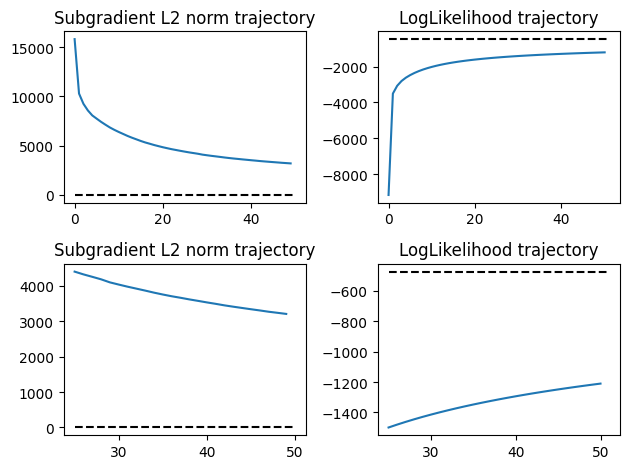

In [331]:
plt.figure()
plt.subplot(221)
plt.plot(np.arange(NITER), params['subgradient_l2_trajectory'])
plt.plot([0, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')


plt.subplot(222)
plt.plot(np.arange(NITER+1), params['loglik_trajectory'])
plt.plot([0, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.subplot(223)
plt.plot(np.arange(NITER//2, NITER), params['subgradient_l2_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER], [0, 0], 'k--')
plt.title('Subgradient L2 norm trajectory')

plt.subplot(224)
plt.plot(np.arange(NITER//2, NITER+1), params['loglik_trajectory'][NITER//2:])
plt.plot([NITER//2, NITER+1], [true_logL, true_logL], 'k--')
plt.title('LogLikelihood trajectory')

plt.tight_layout()

In [332]:
print(params['open_gap_score'], aligner.open_gap_score)
print(params['extend_gap_score'], aligner.extend_gap_score)

[-1.90709157] -1.0
[-0.20770575] -0.1


In [333]:
params['alpha']

-44.567879331308276

In [334]:
blosum_vs_mine = []
for char1 in params['substitution_matrix'].alphabet:
    for char2 in params['substitution_matrix'].alphabet:
        if char1 != 'N' and char2 != 'N':
            blosum_vs_mine.append([char1, char2,blosum62[char1, char2], params['substitution_matrix'][char1, char2]])

In [335]:
print('Blosum, Mine')
for i in rd.choice(len(blosum_vs_mine), 10, replace=False):
    print(blosum_vs_mine[i])

Blosum, Mine
['M', 'Y', -0.01662515560179388, -0.7314207883187804]
['G', 'S', 0.0, -0.1622084945113686]
['P', 'G', -0.03325031120358776, -0.0966635860368927]
['T', 'G', -0.03325031120358776, -0.318430782059466]
['A', 'Y', -0.03325031120358776, -0.2122895257976945]
['H', 'M', -0.03325031120358776, 0.2817241247930328]
['E', 'A', -0.01662515560179388, 0.07353925170021357]
['A', 'C', 0.0, 0.2965257647460072]
['M', 'S', -0.01662515560179388, 0.397984359654686]
['L', 'S', -0.03325031120358776, -0.06714113950960687]


In [336]:
np.corrcoef([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine])

array([[1.        , 0.14812141],
       [0.14812141, 1.        ]])

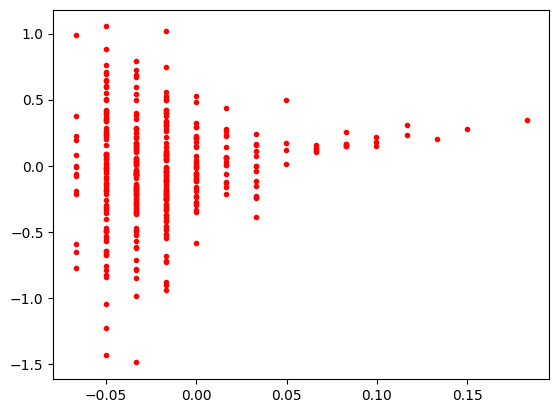

In [337]:
plt.figure()
plt.plot([x[2] for x in blosum_vs_mine], [x[3] for x in blosum_vs_mine], 'r.')

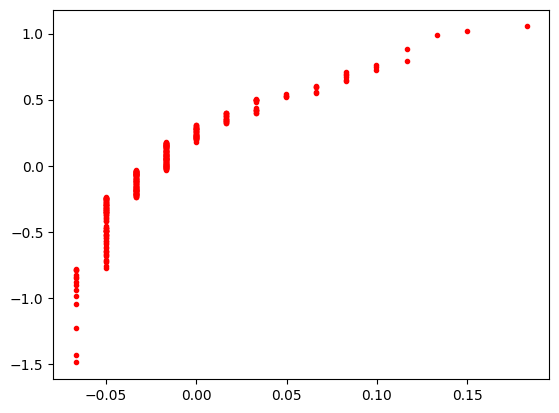

In [338]:
plt.figure()
plt.plot(sorted([x[2] for x in blosum_vs_mine]), sorted([x[3] for x in blosum_vs_mine]), 'r.')